In [2]:
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns
import optuna
from catboost import CatBoostClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.preprocessing import OneHotEncoder


optuna.logging.set_verbosity(optuna.logging.WARNING)

Проведём комплексную очистку датасета.
Восстановим пропущенные значения, находя их по Customer ID. А также добавим индикатор пропусков (так как у должников этот показатель по логике должен появляться чаще, чем у добросовестных кредиторов).

In [3]:
def clean_dataset(data_raw):
    data = data_raw[data_raw['Credit_Score'].isin(['Good', 'Standard', 'Poor'])].copy()

    num_cols = [
        'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
        'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
        'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
        'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month',
        'Amount_invested_monthly', 'Monthly_Balance'
    ]

    for col in num_cols:
        if col in data.columns:
            data[col] = data[col].astype(str).str.replace(r'[^0-9.-]', '', regex=True)
            data[col] = pd.to_numeric(data[col], errors='coerce')


    month_map = {
        'January': 1, 'February': 2, 'March': 3, 'April': 4,
        'May': 5, 'June': 6, 'July': 7, 'August': 8,
        'September': 9, 'October': 10, 'November': 11, 'December': 12
    }
    if 'Month' in data.columns:
        if data['Month'].dtype == 'object':
            data['Month'] = data['Month'].map(month_map).fillna(data['Month'])
        data['Month'] = pd.to_numeric(data['Month'], errors='coerce')
        num_cols.append('Month')

    def extract_months(val):
        if pd.isna(val) or str(val) == 'nan': return np.nan
        parts = re.findall(r'\d+', str(val))
        if len(parts) == 2:
            return int(parts[0]) * 12 + int(parts[1])
        return np.nan

    if 'Credit_History_Age' in data.columns:
        data['Credit_History_Age'] = data['Credit_History_Age'].apply(extract_months)
        num_cols.append('Credit_History_Age')

    if 'Customer_ID' in data.columns:
        for col in num_cols:
            data[col] = data.groupby('Customer_ID')[col].transform(lambda x: x.ffill().bfill())

        cat_temp = data.select_dtypes(include=['object']).columns.tolist()
        for c in ['Credit_Score', 'ID', 'Customer_ID', 'Name', 'SSN']:
            if c in cat_temp: cat_temp.remove(c)
        for col in cat_temp:
            data[col] = data.groupby('Customer_ID')[col].transform(lambda x: x.ffill().bfill())

    for col in num_cols:
        if col in data.columns and data[col].isna().sum() > 0:
            data[f'{col}_isna'] = data[col].isna().astype(int)

    if 'Occupation' in data.columns:
        for col in num_cols:
            if col in data.columns and data[col].isna().sum() > 0:
                data[col] = data.groupby('Occupation')[col].transform(lambda x: x.fillna(x.median()))

    for col in num_cols:
        if col in data.columns and data[col].isna().sum() > 0:
            data[col] = data[col].fillna(data[col].median())

    cat_cols = data.select_dtypes(include=['object']).columns.tolist()
    if 'Credit_Score' in cat_cols: cat_cols.remove('Credit_Score')

    for col in cat_cols:
        data[col] = data[col].replace([r'^\s*_\s*$', r'^\s*$'], np.nan, regex=True)

    for col in cat_cols:
        data[col] = data[col].fillna('Unknown').astype(str)

    drop_cols = ['ID', 'Customer_ID', 'Name', 'SSN']
    data = data.drop(columns=[c for c in drop_cols if c in data.columns])

    cat_cols = [c for c in cat_cols if c not in drop_cols]

    for col in data.select_dtypes(include=['float64']).columns:
        data[col] = data[col].astype(np.float32)
    for col in data.select_dtypes(include=['int64']).columns:
        data[col] = data[col].astype(np.int32)

    return data, cat_cols

In [6]:
data = pd.read_csv('train.csv')

df, cat_features = clean_dataset(data)

/tmp/ipykernel_1089/134622388.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data.groupby('Customer_ID')[col].transform(lambda x: x.ffill().bfill())


In [7]:
X = df.drop("Credit_Score", axis=1)
y = df["Credit_Score"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Оптимизация гиперпараметров Random Forest с Optuna. Для оптимизации процесса обучения берём подвыборку X_opt, y_opt

In [8]:
min_class_size = y.value_counts().min()
k_neighbors = min(5, max(1, min_class_size - 1))

skf_sample = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
sample_idx, _ = next(skf_sample.split(X, y))

X_opt = X.iloc[sample_idx].reset_index(drop=True)
y_opt = y.iloc[sample_idx].reset_index(drop=True)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X_sub, _, y_sub, _ = train_test_split(X, y, train_size=0.3, stratify=y, random_state=42)
X_tr_opt, X_va_opt, y_tr_opt, y_va_opt = train_test_split(X_sub, y_sub, test_size=0.2, stratify=y_sub, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_features)
    ]
)

def objective_rf(trial):
  n_estimators = trial.suggest_int('n_estimators', 50, 120)
  max_depth = trial.suggest_int('max_depth', 10, 20)
  min_samples_split = trial.suggest_int('min_samples_split', 2, 10)

  rf_model = RandomForestClassifier(
      n_estimators=n_estimators,
      max_depth=max_depth,
      min_samples_split=min_samples_split,
      class_weight='balanced',
      random_state=42,
      n_jobs=1
  )

  pipeline = ImbPipeline([
      ('prep', preprocessor),
      ('rf', rf_model)
  ])

  scores = []
  for train_idx, val_idx in skf.split(X_opt, y_opt):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    pipeline.fit(X_train, y_train)
    predicts = pipeline.predict(X_val)
    scores.append(f1_score(y_val, predicts, average='macro'))

  gc.collect()
  return np.mean(scores)

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10, show_progress_bar=True)
print(f'Best params of RandomForestClassifier: {study_rf.best_params}')

  0%|          | 0/10 [00:00<?, ?it/s]

Best params of RandomForestClassifier: {'n_estimators': 60, 'max_depth': 20, 'min_samples_split': 10}


Оптимизация гиперпараметров CatBoostClassifier. Обучаем на GPU для ускорения процесса.

In [9]:
def objective_cb(trial):
  iterations = trial.suggest_int('iterations', 200, 400)
  learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1)
  depth = trial.suggest_int('depth', 4, 8)
  l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 0.03, 0.15, log=True)

  cb_model = CatBoostClassifier(
            iterations=iterations,
            depth=depth,
            learning_rate=learning_rate,
            cat_features=cat_features,
            loss_function='MultiClass',
            task_type='GPU',
            random_seed=42,
            verbose=0
        )

  pipeline = ImbPipeline([
            ('ros', RandomOverSampler(random_state=42)),
            ('cb', cb_model)
        ])

  pipeline.fit(X_tr_opt, y_tr_opt)
  preds = pipeline.predict(X_va_opt)
  score = f1_score(y_va_opt, preds, average='macro')

  gc.collect()
  return score

study_cb = optuna.create_study(direction='maximize')
study_cb.optimize(objective_cb, n_trials=10, show_progress_bar=True)
print(f"Лучшие параметры CatBoost: {study_cb.best_params}")

  0%|          | 0/10 [00:00<?, ?it/s]

Лучшие параметры CatBoost: {'iterations': 389, 'learning_rate': 0.05380229057797743, 'depth': 7, 'l2_leaf_reg': 0.09044130498105316}


Получили следующие значения f1_score для Random Forest: 0.65288
Best params of RandomForestClassifier: {'n_estimators': 79, 'max_depth': 19, 'min_samples_split': 3}

И для CatBoost: 0.708303
Best params of CatBoost: {'iterations': 358, 'learning_rate': 0.08988500193057783, 'depth': 8, 'l2_leaf_reg': 0.057502008550760056}

Очищаем память от вспомогательных переменных и производим обучение моделей на полных выборках.

In [10]:
del X_sub, y_sub, X_tr_opt, X_va_opt, y_tr_opt, y_va_opt
gc.collect()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_rf_pipe = ImbPipeline([
        ('prep', preprocessor),
        ('rf', RandomForestClassifier(**study_rf.best_params, class_weight='balanced', random_state=42, n_jobs=-1))
    ])

best_cb_pipe = ImbPipeline([
    ('ros', RandomOverSampler(random_state=42)),
    ('cb', CatBoostClassifier(**study_cb.best_params, cat_features=cat_features, loss_function='MultiClass', task_type='GPU', random_seed=42, verbose=0))
])

rf_scores = []
cb_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

    best_rf_pipe.fit(X_tr, y_tr)
    rf_preds = best_rf_pipe.predict(X_va)
    rf_f1 = f1_score(y_va, rf_preds, average='macro')
    rf_scores.append(rf_f1)

    best_cb_pipe.fit(X_tr, y_tr)
    cb_preds = best_cb_pipe.predict(X_va)
    cb_f1 = f1_score(y_va, cb_preds, average='macro')
    cb_scores.append(cb_f1)

    print(f"Fold {fold} | RF F1: {rf_f1:.4f} | CatBoost F1: {cb_f1:.4f}")
    gc.collect()

Fold 1 | RF F1: 0.6543 | CatBoost F1: 0.7526
Fold 2 | RF F1: 0.6678 | CatBoost F1: 0.7632
Fold 3 | RF F1: 0.6615 | CatBoost F1: 0.7627
Fold 4 | RF F1: 0.6592 | CatBoost F1: 0.7682
Fold 5 | RF F1: 0.6630 | CatBoost F1: 0.7641


Проведём статистическое A/B тестирование, чтобы выявить значительную ли разницу показывают модели

In [12]:
t_stat, p_value = stats.ttest_ind(rf_scores, cb_scores)
print(f"Random Forest Classifier F1-score Macro: {np.mean(rf_scores):.4f} (+- {np.std(rf_scores):.4f})")
print(f"CatBoost Classifier F1-score Macro: {np.mean(cb_scores):.4f} (+- {np.std(cb_scores):.4f})")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Разница в результатах статистически значима. CatBoost значительно превосходит в качестве Random Forest")
else:
    print("Разница в результатах не является статистически значимой.")

Random Forest Classifier F1-score Macro: 0.6611 (+- 0.0045)
CatBoost Classifier F1-score Macro: 0.7622 (+- 0.0052)
t-statistic: -29.5798
p-value: 0.0000
Разница в результатах статистически значима. CatBoost значительно превосходит в качестве Random Forest


Визуализация A/B тестирования

/tmp/ipykernel_13487/1019437118.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 1], data=df_scores, x='Model', y='F1_Macro', palette=['#3498db', '#2ecc71'], width=0.4, boxprops=dict(alpha=0.7))


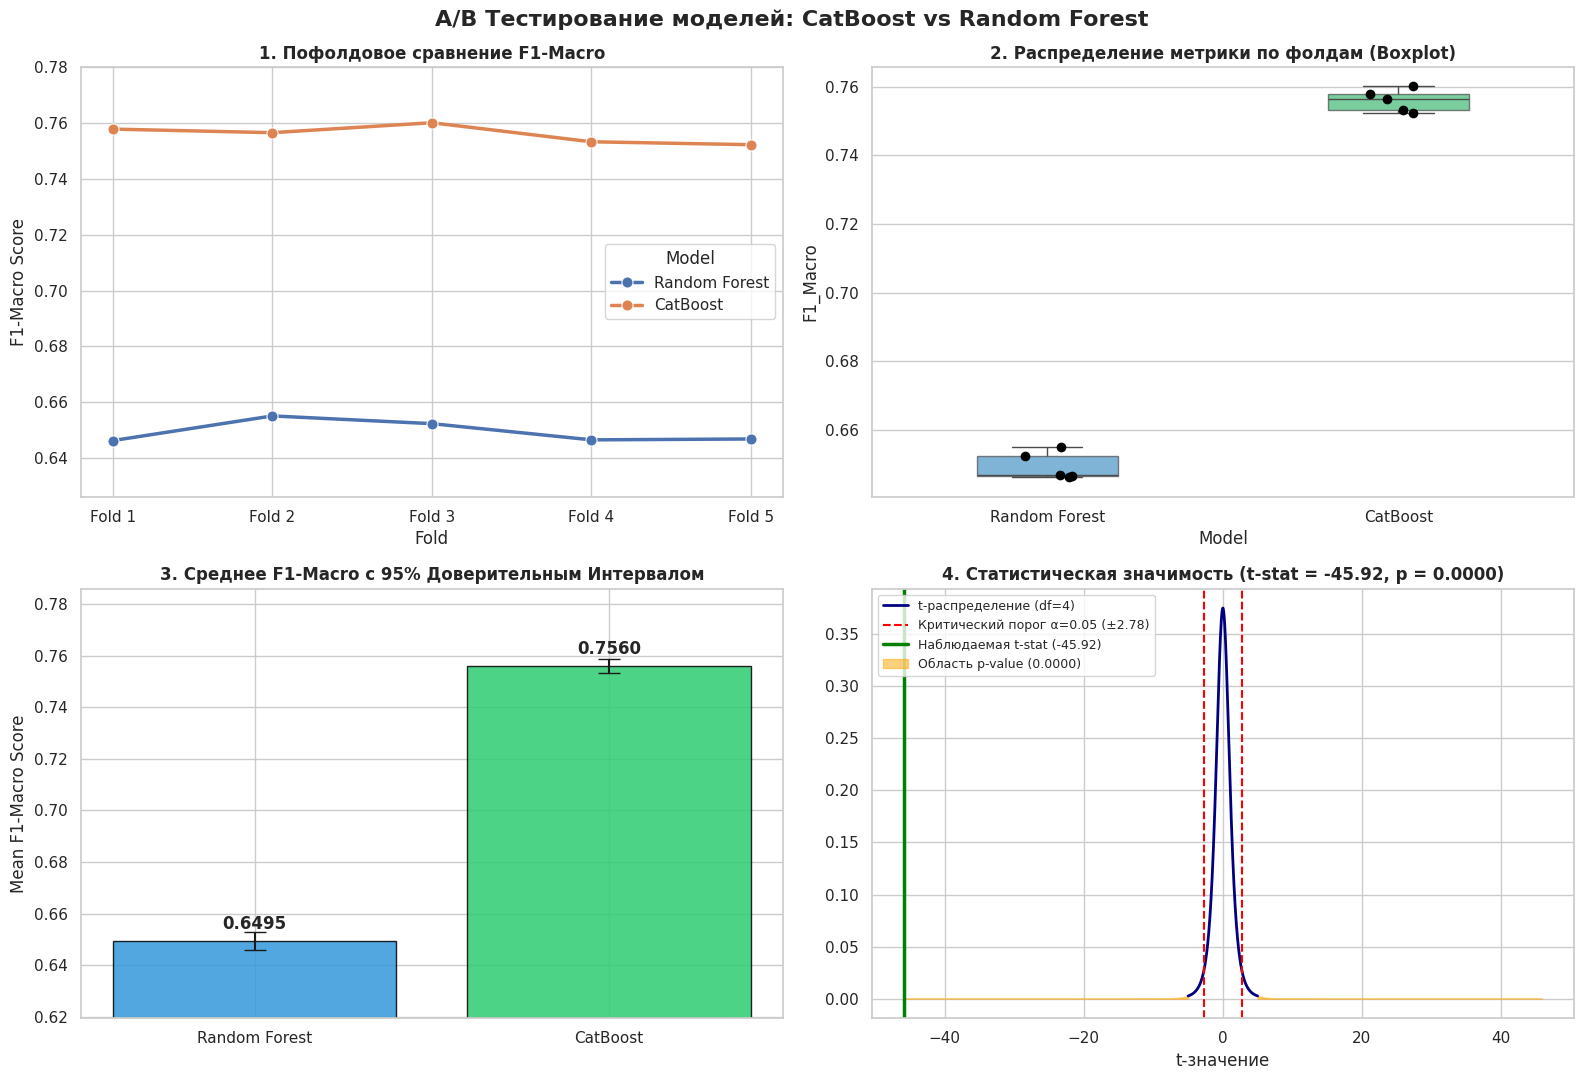

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('A/B Тестирование моделей: CatBoost vs Random Forest', fontsize=16, fontweight='bold', y=0.98)
sns.set_theme(style="whitegrid")

folds = [f"Fold {i}" for i in range(1, 6)]
df_scores = pd.DataFrame({
    'Fold': folds * 2,
    'F1_Macro': rf_scores + cb_scores,
    'Model': ['Random Forest'] * 5 + ['CatBoost'] * 5
})

sns.lineplot(ax=axes[0, 0], data=df_scores, x='Fold', y='F1_Macro', hue='Model', marker='o', linewidth=2.5, markersize=8)
axes[0, 0].set_title('1. Пофолдовое сравнение F1-Macro', fontsize=12, fontweight='semibold')
axes[0, 0].set_ylabel('F1-Macro Score')
axes[0, 0].set_ylim(min(rf_scores + cb_scores) - 0.02, max(rf_scores + cb_scores) + 0.02)


sns.boxplot(ax=axes[0, 1], data=df_scores, x='Model', y='F1_Macro', palette=['#3498db', '#2ecc71'], width=0.4, boxprops=dict(alpha=0.7))
sns.stripplot(ax=axes[0, 1], data=df_scores, x='Model', y='F1_Macro', color='black', size=7, jitter=0.1)
axes[0, 1].set_title('2. Распределение метрики по фолдам (Boxplot)', fontsize=12, fontweight='semibold')

means = [np.mean(rf_scores), np.mean(cb_scores)]
stds = [np.std(rf_scores, ddof=1), np.std(cb_scores, ddof=1)]
se = [s / np.sqrt(5) for s in stds]
ci95 = [1.96 * s for s in se]

bars = axes[1, 0].bar(['Random Forest', 'CatBoost'], means, yerr=ci95, capsize=8, color=['#3498db', '#2ecc71'], alpha=0.85, edgecolor='black')
axes[1, 0].set_title('3. Среднее F1-Macro с 95% Доверительным Интервалом', fontsize=12, fontweight='semibold')
axes[1, 0].set_ylabel('Mean F1-Macro Score')
axes[1, 0].set_ylim(min(means) - 0.03, max(means) + 0.03)
for bar in bars:
    yval = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, yval + 0.003, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

df_deg = len(rf_scores) - 1
x = np.linspace(-5, 5, 500)
y_dist = stats.t.pdf(x, df=df_deg)

axes[1, 1].plot(x, y_dist, label=f't-распределение (df={df_deg})', color='navy', linewidth=2)
t_crit = stats.t.ppf(0.975, df=df_deg)
axes[1, 1].axvline(t_crit, color='red', linestyle='--', label=f'Критический порог α=0.05 (±{t_crit:.2f})')
axes[1, 1].axvline(-t_crit, color='red', linestyle='--')
axes[1, 1].axvline(t_stat, color='green', linewidth=2.5, label=f'Наблюдаемая t-stat ({t_stat:.2f})')

x_fill = np.linspace(abs(t_stat), 5, 100)
axes[1, 1].fill_between(x_fill, stats.t.pdf(x_fill, df=df_deg), color='orange', alpha=0.5, label=f'Область p-value ({p_value:.4f})')
axes[1, 1].fill_between(-x_fill, stats.t.pdf(-x_fill, df=df_deg), color='orange', alpha=0.5)

axes[1, 1].set_title(f'4. Статистическая значимость (t-stat = {t_stat:.2f}, p = {p_value:.4f})', fontsize=12, fontweight='semibold')
axes[1, 1].set_xlabel('t-значение')
axes[1, 1].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('ab_test_results.png', dpi=300)
plt.show()

F1-macro хорошо показывает качество на 3 классах, но для скоринга индустриальный стандарт — ROC-AUC/Gini, так как они не зависят от порога отсечения и напрямую показывают, насколько хорошо модель ранжирует заёмщиков по риску. Сведём задачу к бинарной: `Poor` (дефолт) против остальных, и посчитаем ROC-AUC/Gini на той же кросс-валидации, что и раньше, заодно сохранив out-of-fold предсказания для дальнейшей бизнес-оценки.

In [13]:
from sklearn.metrics import roc_auc_score

y_bin = (y == 'Poor').astype(int)

oof_proba_rf = np.zeros(len(y))
oof_proba_cb = np.zeros(len(y))

rf_auc_scores = []
cb_auc_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
    y_va_bin = y_bin.iloc[val_idx]

    best_rf_pipe.fit(X_tr, y_tr)
    rf_proba = best_rf_pipe.predict_proba(X_va)[:, list(best_rf_pipe.classes_).index('Poor')]
    oof_proba_rf[val_idx] = rf_proba
    rf_auc = roc_auc_score(y_va_bin, rf_proba)
    rf_auc_scores.append(rf_auc)

    best_cb_pipe.fit(X_tr, y_tr)
    cb_proba = best_cb_pipe.predict_proba(X_va)[:, list(best_cb_pipe.classes_).index('Poor')]
    oof_proba_cb[val_idx] = cb_proba
    cb_auc = roc_auc_score(y_va_bin, cb_proba)
    cb_auc_scores.append(cb_auc)

    print(f"Fold {fold} | RF ROC-AUC: {rf_auc:.4f} | CatBoost ROC-AUC: {cb_auc:.4f}")
    gc.collect()


Fold 1 | RF ROC-AUC: 0.8526 | CatBoost ROC-AUC: 0.9181
Fold 2 | RF ROC-AUC: 0.8576 | CatBoost ROC-AUC: 0.9227
Fold 3 | RF ROC-AUC: 0.8640 | CatBoost ROC-AUC: 0.9242
Fold 4 | RF ROC-AUC: 0.8681 | CatBoost ROC-AUC: 0.9310
Fold 5 | RF ROC-AUC: 0.8698 | CatBoost ROC-AUC: 0.9282


In [14]:
t_stat_auc, p_value_auc = stats.ttest_ind(rf_auc_scores, cb_auc_scores)

rf_gini_scores = [2 * a - 1 for a in rf_auc_scores]
cb_gini_scores = [2 * a - 1 for a in cb_auc_scores]

print(f"Random Forest ROC-AUC: {np.mean(rf_auc_scores):.4f} (+- {np.std(rf_auc_scores):.4f}) | "
      f"Gini: {np.mean(rf_gini_scores):.4f}")
print(f"CatBoost Classifier ROC-AUC: {np.mean(cb_auc_scores):.4f} (+- {np.std(cb_auc_scores):.4f}) | "
      f"Gini: {np.mean(cb_gini_scores):.4f}")
print(f"t-statistic: {t_stat_auc:.4f}")
print(f"p-value: {p_value_auc:.4f}")

if p_value_auc < 0.05:
    print("Разница в Gini статистически значима. CatBoost лучше ранжирует заёмщиков по риску, чем Random Forest")
else:
    print("Разница в Gini не является статистически значимой.")


Random Forest ROC-AUC: 0.8624 (+- 0.0064) | Gini: 0.7248
CatBoost Classifier ROC-AUC: 0.9248 (+- 0.0045) | Gini: 0.8497
t-statistic: -15.9355
p-value: 0.0000
Разница в Gini статистически значима. CatBoost лучше ранжирует заёмщиков по риску, чем Random Forest


Переведём качество модели в понятную бизнесу метрику: как изменится NPL (доля дефолтов в портфеле), если отсекать самых рискованных заёмщиков по PD-скору модели. Используем CatBoost — как модель с более высоким Gini — и его предсказания (честная оценка, без утечки данных из обучающей выборки).

In [15]:
df_business = pd.DataFrame({
    'pd_score': oof_proba_cb,
    'is_default': y_bin.values
})

df_business['decile'] = pd.qcut(df_business['pd_score'], 10, labels=False, duplicates='drop')

npl_by_decile = df_business.groupby('decile')['is_default'].mean().sort_index()
print("NPL (доля Poor) по децилям PD-скора (0 = самые надёжные, 9 = самые рискованные):")
print(npl_by_decile)

overall_npl = df_business['is_default'].mean()
worst_decile = df_business['decile'].max()
accepted = df_business[df_business['decile'] != worst_decile]
npl_after = accepted['is_default'].mean()
npl_reduction_pct = (overall_npl - npl_after) / overall_npl * 100

print(f"\nБазовый NPL по всему портфелю: {overall_npl:.2%}")
print(f"NPL после отсечения худшего дециля (10% самых рискованных заёмщиков): {npl_after:.2%}")
print(f"Относительное снижение NPL: {npl_reduction_pct:.1f}%")


NPL (доля Poor) по децилям PD-скора (0 = самые надёжные, 9 = самые рискованные):
decile
0    0.000000
1    0.000987
2    0.009214
3    0.026316
4    0.055939
5    0.145443
6    0.383224
7    0.690030
8    0.769332
9    0.827961
Name: is_default, dtype: float64

Базовый NPL по всему портфелю: 29.08%
NPL после отсечения худшего дециля (10% самых рискованных заёмщиков): 23.12%
Относительное снижение NPL: 20.5%


Переведём снижение NPL в деньги. Ниже — гипотетические допущения (средний размер кредита, LGD, размер портфеля), не основанные на реальных данных конкретного банка, были взяты примерные данные, чтобы показать порядок величины потенциального эффекта.

In [18]:
avg_loan = 211_000        # средний размер кредита, руб.
lgd = 0.6                 # доля невозвратной части при дефолте
portfolio_size = 50_000   # гипотетический размер портфеля заёмщиков

el_before = overall_npl * avg_loan * lgd * portfolio_size
el_after = npl_after * avg_loan * lgd * portfolio_size
savings = el_before - el_after

print(f"Допущения: средний кредит = {avg_loan:,} руб., LGD = {lgd:.0%}, портфель = {portfolio_size:,} заёмщиков")
print(f"Ожидаемые потери (Expected Loss) до модели: {el_before / 1e6:.1f} млн руб/год")
print(f"Ожидаемые потери после отсечения худшего дециля: {el_after / 1e6:.1f} млн руб/год")
print(f"Потенциальная экономия резервов: {savings / 1e6:.1f} млн руб/год")


Допущения: средний кредит = 211,000 руб., LGD = 60%, портфель = 50,000 заёмщиков
Ожидаемые потери (Expected Loss) до модели: 1841.1 млн руб/год
Ожидаемые потери после отсечения худшего дециля: 1463.2 млн руб/год
Потенциальная экономия резервов: 377.9 млн руб/год
